# Training Cellpose on circles

Here we train cellpose on circles of different diameters.  As a test to see how cellpose deals with objects of different sizes. 

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import tifffile
from skimage.color import label2rgb
from skimage.measure import regionprops
from tnia.plotting.plt_helper import imshow_multi2d

import skop
from skop.ops.segment import cellpose3, cellpose4
from skop.ops.segment.cellpose3 import PretrainedModel
from skop.ops.segment.cellpose4 import PretrainedModel as Cellpose4Model
from skop.ops.train import train_cellpose3, train_cellpose4

import circles

plt.rcParams["figure.dpi"] = 72

# Which model to finetune. The three cellpose4 backbones are bigger than
# cyto3 and want much more GPU memory.
MODEL = "cellpose3_cyto3"   # cellpose3_cyto3 | cpsam_v2 | cpdino | cpdino_vitb

if MODEL == "cpsam_v2":
    cellpose4_model = Cellpose4Model.cpsam_v2
if MODEL == "cpdino":
    cellpose4_model = Cellpose4Model.cpdino
if MODEL == "cpdino_vitb":
    cellpose4_model = Cellpose4Model.cpdino_vitb

WORK = Path("/tmp/skop_circles")
RADII = [3, 5, 15, 30, 60, 70]

##  Create the callback

Here we create a callback to monitor the training. 

In [7]:
runner = skop.Runner()

# What the last event said, so an event that carries only a counter keeps
# the message and maximum it was sent with instead of blanking them.
_last = {"build": None, "msg": "", "max": None}


def on_build(title, current, maximum):
    if title != _last["build"]:
        _last["build"] = title
        print("  [build]", title)


def show_progress(ev):
    if ev.message is None and ev.current is None:
        return  # a status event, not progress

    if ev.message is not None:
        _last["msg"] = ev.message
    if ev.maximum is not None:
        _last["max"] = ev.maximum

    count = ""
    if ev.current is not None:
        count = f"{ev.current}"
        if _last["max"]:
            count += f"/{_last['max']}"

    print(f"{count}  {_last['msg']}", flush=True)


runner.subscribe_build_progress(on_build)

## Training data

Ten images of non-overlapping circles, radii 1-85, random positions.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12847381830215454..1.1432065129280091].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13649165630340576..1.1269325375556947].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12135442346334457..1.130935823917389].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13366268575191498..1.1280089378356934].


10 pairs, 120 circles


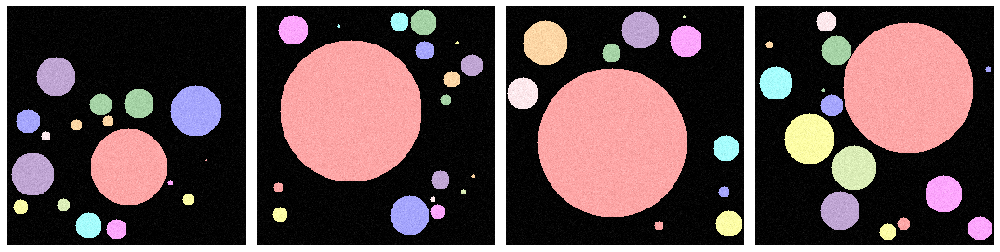

In [8]:
(WORK / "input").mkdir(parents=True, exist_ok=True)
(WORK / "truth").mkdir(parents=True, exist_ok=True)

train_imgs, train_lbls = circles.random(10, size=256, min_r=1, max_r=85, seed=1)

images, truths = [], []
for i, (img, lbl) in enumerate(zip(train_imgs, train_lbls)):
    tifffile.imwrite(WORK / "input" / f"{i:03d}.tif", img)
    tifffile.imwrite(WORK / "truth" / f"{i:03d}.tif", lbl)
    images.append(str(WORK / "input" / f"{i:03d}.tif"))
    truths.append(str(WORK / "truth" / f"{i:03d}.tif"))

print(len(images), "pairs,", sum(int(l.max()) for l in train_lbls), "circles")

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, img, lbl in zip(axes, train_imgs, train_lbls):
    ax.imshow(label2rgb(lbl, image=img, bg_label=0, alpha=0.35))
    ax.axis("off")
fig.tight_layout()

## Train

Train whichever model `MODEL` names. Four choices, two ops.

In [9]:
# Retire the worker first: ipykernel binds a thread's output to the execution
# that created it, so a reused worker prints the first run only.
runner.close()

if MODEL == "cpsam_v2" or MODEL == "cpdino" or MODEL == "cpdino_vitb":
    model_path = runner.run(
        train_cellpose4,
        images=images,
        labels=truths,
        model_dir=str(WORK),
        name=f"circles_{MODEL}",
        model=cellpose4_model,
        epochs=100,
        batch_size=1,
        patch_size=256,
        val_size=2,
        on_progress=show_progress,
    )
else:
    model_path = runner.run(
        train_cellpose3,
        images=images,
        labels=truths,
        model_dir=str(WORK),
        name=f"circles_{MODEL}",
        model=PretrainedModel.cyto3,
        epochs=100,
        batch_size=8,
        patch_size=224,
        val_size=2,
        on_progress=show_progress,
    )

print(model_path)

0/10  Reading 10 pairs
1/10  Reading 10 pairs
2/10  Reading 10 pairs
3/10  Reading 10 pairs
4/10  Reading 10 pairs
5/10  Reading 10 pairs
6/10  Reading 10 pairs
7/10  Reading 10 pairs
8/10  Reading 10 pairs
9/10  Reading 10 pairs
10/10  Reading 10 pairs
  Loading Cellpose 3 model cyto3
0/100  Training circles_cellpose3_cyto3: 8 train, 2 val, 100 epochs
1/100  Epoch 1/100 — loss 3.6593, val_loss 0.9429
6/100  Epoch 6/100 — loss 2.8979, val_loss 0.0900
11/100  Epoch 11/100 — loss 1.6451, val_loss 0.0485
21/100  Epoch 21/100 — loss 0.7806, val_loss 0.0314
31/100  Epoch 31/100 — loss 0.5025, val_loss 0.0331
41/100  Epoch 41/100 — loss 0.3382, val_loss 0.0367
51/100  Epoch 51/100 — loss 0.2266, val_loss 0.0261
61/100  Epoch 61/100 — loss 0.2121, val_loss 0.0318
71/100  Epoch 71/100 — loss 0.2780, val_loss 0.0253
81/100  Epoch 81/100 — loss 0.2698, val_loss 0.0263
91/100  Epoch 91/100 — loss 0.2181, val_loss 0.0213
\tmp\skop_circles\models\circles_cellpose3_cyto3


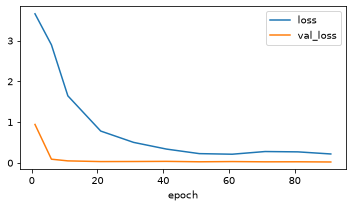

In [10]:
# One row per epoch, appended to on every further run of this model.
import csv

with open(f"{model_path}_history.csv") as f:
    history = list(csv.DictReader(f))

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot([int(r["epoch"]) for r in history], [float(r["loss"]) for r in history], label="loss")
ax.plot([int(r["epoch"]) for r in history], [float(r["val_loss"]) for r in history], label="val_loss")
ax.set_xlabel("epoch")
ax.legend()
fig.tight_layout()

## Predict

One circle per radius, none of them a size the model trained on.

`diameter=0` means "use the diameter the model was trained at" -- Cellpose saved
the mean of the training labels into the model. There is only one such number,
and these circles span 6 to 140 px, which is the hard part.

(256, 534) diameters [6, 10, 30, 60, 120, 140]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1460587978363037..1.1200647711753846].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1460587978363037..1.1537886023521424].


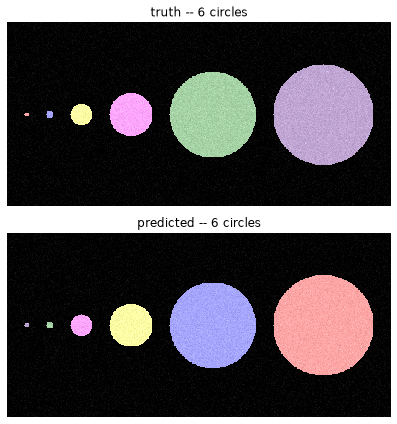

In [11]:
test_img, test_lbl = circles.calibration(RADII)
print(test_img.shape, "diameters", [2 * r for r in RADII])

if MODEL == "cpsam_v2" or MODEL == "cpdino" or MODEL == "cpdino_vitb":
    predicted = runner.run(
        cellpose4,
        image=test_img,
        model=cellpose4_model,
        pretrained_model=model_path,
    )
else:
    predicted = runner.run(
        cellpose3, image=test_img, pretrained_model=model_path, diameter=0.0
    )

fig, axes = plt.subplots(2, 1, figsize=(13, 6))
axes[0].imshow(label2rgb(test_lbl, image=test_img, bg_label=0, alpha=0.35))
axes[0].set_title(f"truth -- {test_lbl.max()} circles")
axes[1].imshow(label2rgb(predicted, image=test_img, bg_label=0, alpha=0.35))
axes[1].set_title(f"predicted -- {predicted.max()} circles")
for ax in axes:
    ax.axis("off")
fig.tight_layout()

## Does training enable us to detect objects at scale?

... better than the builtin models? 


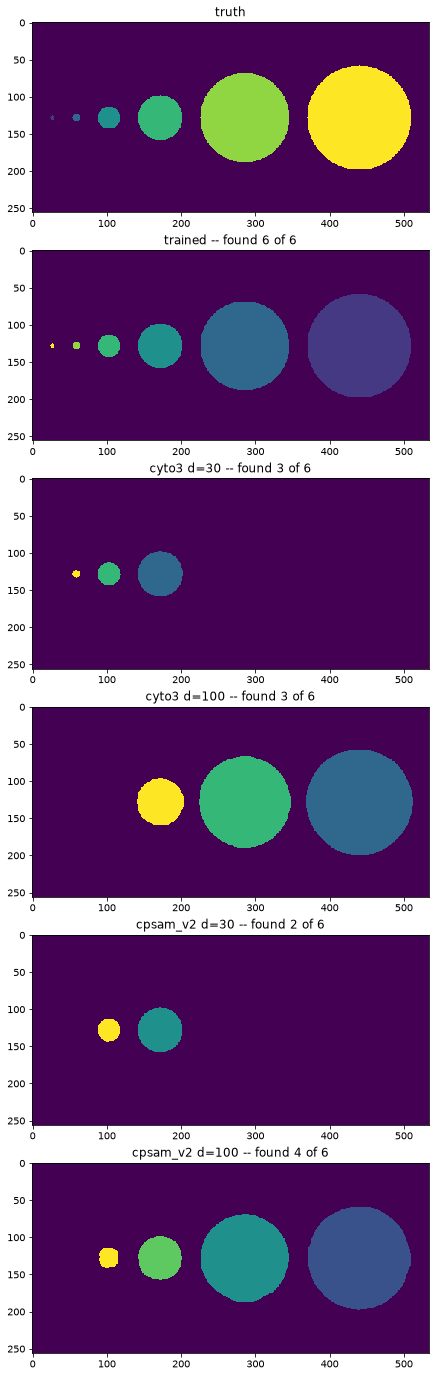

In [12]:
def hits(result):
    """True circles whose centre landed in a detected mask."""
    return sum(
        1 for pr in regionprops(test_lbl)
        if result[int(pr.centroid[0]), int(pr.centroid[1])]
    )

baselines = {
    "cyto3 d=30": (cellpose3, dict(model=PretrainedModel.cyto3, diameter=30.0)),
    "cyto3 d=100": (cellpose3, dict(model=PretrainedModel.cyto3, diameter=100.0)),
    "cpsam_v2 d=30": (
        cellpose4,
        dict(model=Cellpose4Model.cpsam_v2, diameter=30.0),
    ),
    "cpsam_v2 d=100": (
        cellpose4,
        dict(model=Cellpose4Model.cpsam_v2, diameter=100.0),
    ),
}

results = {"truth": test_lbl, "trained": predicted}
for label, (op, kwargs) in baselines.items():
    results[label] = runner.run(op, image=test_img, **kwargs)
    runner.release()

titles = [
    name if name == "truth" else f"{name} -- found {hits(im)} of {test_lbl.max()}"
    for name, im in results.items()
]
fig = imshow_multi2d(list(results.values()), titles, len(results), 1, width=12, height=4 * len(results))

In [10]:
runner.close()